### Trajectory analysis

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import skmob
from skmob.preprocessing import detection, clustering

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)
import warnings
warnings.simplefilter("ignore")

### prepare data

In [2]:
events = pd.read_csv("GalapagostortoiseMovementEcology Programme_2009_2018.csv", sep=',', parse_dates=[2])
new_cols = pd.Series(events.columns.values).str.replace(pat = r"[-:]", repl="_")
tortoise = events.set_axis(labels = new_cols, axis =1)
tortoise.drop(tortoise.index[tortoise["manually_marked_outlier"].notna()], inplace = True)
tortoise.drop(columns =["manually_marked_outlier"], inplace=True)
tortoise.drop(index = tortoise.index[tortoise.isna().any(axis=1)], inplace=True)
cols = ['event_id', 'timestamp', 'location_long', 'location_lat',
       'eobs_temperature', 'ground_speed', 'heading', 'height_above_ellipsoid',
       #'individual_taxon_canonical_name', 'tag_local_identifier',
       'individual_local_identifier']
tortoise = tortoise[cols].assign()
tortoise.insert(loc = 2, column = "timestamp_UTC",
    value = tortoise['timestamp'].apply(lambda x: x.tz_localize(tz='UTC'))
)
tortoise.insert(loc = 3, column = "timestamp_local", 
    value = tortoise["timestamp_UTC"].apply(lambda x: x.tz_convert(tz='US/Pacific'))
)

tortoise.sort_values(by = ["individual_local_identifier", "timestamp_local"], inplace=True)

tortoise.insert(loc = 4, column = "minute_diff", 
    value = tortoise.groupby(['individual_local_identifier'])["timestamp_local"].diff()\
        .apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')
)

tortoise['year'] = tortoise["timestamp_local"].dt.year
tortoise['month'] = tortoise["timestamp_local"].dt.month
tortoise['date'] = tortoise["timestamp_local"].dt.date

### trajectory
 - use local time zone

In [3]:
tortoise_trajectory = skmob.TrajDataFrame(tortoise, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local', \
)

 - get Alison data for experiment

In [4]:
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]
alison_trajectory = tortoise_trajectory.query("uid == 'Alison'")

In [5]:
alison_trajectory.shape

(40003, 15)

In [6]:
map_f = alison_trajectory.query("year == 2012").plot_trajectory(zoom=14, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#883399')
alison_trajectory.query("year == 2013").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#66c066')
alison_trajectory.query("year == 2014").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#ff800c')
alison_trajectory.query("year == 2015").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#60ff78')
alison_trajectory.query("year == 2016").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#301e4b')
map_f


### tesselation as RoI

In [7]:
from skmob.tessellation import tilers
from skmob.preprocessing import filtering
tessellation = tilers.tiler.get("h3_tessellation", base_shape="isla santa cruz", meters=20)
tessellation["tile_lng"] = tessellation.geometry.centroid.x
tessellation["tile_lat"] = tessellation.geometry.centroid.y

 - get some basic understanding of tesselation

In [8]:
tessellation.dtypes

geometry    geometry
H3_INDEX      uint64
tile_ID       object
tile_lng     float64
tile_lat     float64
dtype: object

In [9]:
type(tessellation.tile_ID[0])

str

In [10]:
type(tessellation["geometry"][0])

shapely.geometry.polygon.Polygon

In [36]:
tessellation.iloc[221].geometry,tessellation.iloc[222].geometry

(<POLYGON ((-90.383 -0.514, -90.383 -0.514, -90.383 -0.515, -90.383 -0.515, -...>,
 <POLYGON ((-90.349 -0.516, -90.349 -0.516, -90.349 -0.516, -90.348 -0.516, -...>)

In [34]:
tessellation.iloc[221].geometry.touches(tessellation.iloc[220].geometry)

False

In [12]:
tessellation.iloc[221].geometry.centroid.hausdorff_distance(tessellation.iloc[222].geometry.centroid)

0.034530978327423335

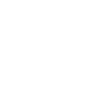

In [14]:
tessellation.iloc[221]["geometry"]

In [15]:
tessellation.iloc[221]["geometry"].area*1000*1000 # area unit is square meters

0.1975776409785737

In [16]:
tessellation.iloc[0].geometry.hausdorff_distance(tessellation.iloc[3].geometry)

0.1697471607650181

In [13]:
tessellation.iloc[221]["geometry"].bounds

(-90.38330006215482,
 -0.5146754401670542,
 -90.38275152197883,
 -0.514170804375175)

In [17]:
[tessellation.iloc[221].geometry.centroid.x, tessellation.iloc[221].geometry.centroid.y]

[-90.38302579211985, -0.5144231222146345]

### mapping trajectory into tesselation

In [18]:
tortoise_trajectory_mapping = tortoise_trajectory.mapping(tessellation)
tortoise_trajectory_mapping_deduped = tortoise_trajectory_mapping.drop_duplicates(subset=['uid','date','tile_ID'])

### deduping by date is actually not quite right
 - the zig-zag portion will be remvoed as such

In [19]:
tortoise_trajectory_mapping.shape, tortoise_trajectory.shape, tortoise_trajectory_mapping_deduped.shape

((1795892, 16), (1795892, 15), (246578, 16))

In [37]:
tortoise_trajectory.plot_trajectory(start_end_markers= False, tiles = 'OpenStreetMap')

In [21]:
tortoise_trajectory_mapping_deduped.plot_trajectory(tiles = 'OpenStreetMap')

 - reduced to 6% of events when meter = 500 for tesselation
 - reduced to 9% when meter = 50
 - reduced to 13% when meter = 20

In [22]:
tortoise_trejctory_mapping_deduped = tortoise_trajectory_mapping.merge(tessellation, on = "tile_ID").drop_duplicates(subset=["uid","date", "tile_ID"])
tortoise_trejctory_mapping_deduped.sort_values(by = ["uid", "datetime"], inplace=True)
# drop the lat/lng so that we can create new trajectory
tortoise_trejctory_mapping_deduped.drop(columns =["lat","lng"], inplace=True)
tortoise_trajectory_mapping_deduped_trajectory = skmob.TrajDataFrame(tortoise_trejctory_mapping_deduped, latitude='tile_lat', longitude='tile_lng', \
    user_id='uid', datetime='datetime', \
)
tortoise_trajectory_mapping_deduped_trajectory.shape
tortoise_trajectory_mapping_deduped_trajectory.plot_trajectory()


In [23]:
alison_deduped_trajectory = tortoise_trajectory_mapping_deduped_trajectory.query("uid == 'Alison'")

In [26]:
map_f = alison_trajectory.query("year == 2012").plot_trajectory(zoom=14, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#883399')
alison_trajectory.query("year == 2013").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#66c066')
alison_trajectory.query("year == 2014").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#ff800c')
alison_trajectory.query("year == 2015").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#60ff78')
alison_trajectory.query("year == 2016").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#301e4b')
map_f


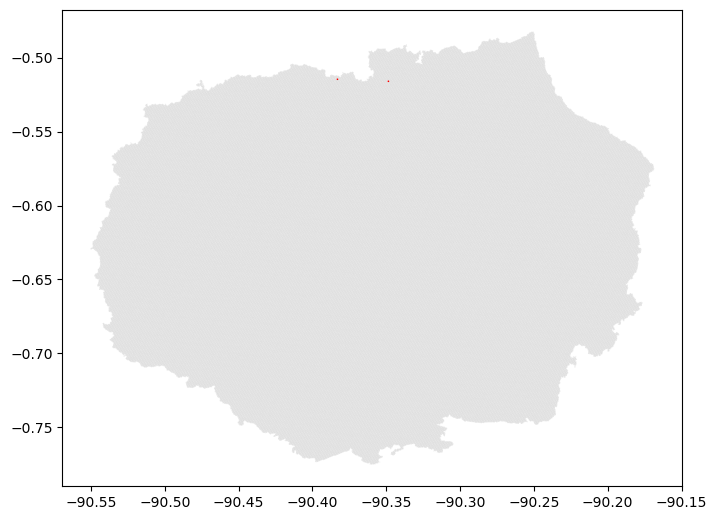

In [38]:
fig, ax = plt.subplots(figsize = (8,8))
tessellation["geometry"].boundary.plot(color="lightgrey", ax=ax, linewidth=0.1)
tessellation.query("tile_ID == '221' or tile_ID =='222'")["geometry"].boundary.plot(color="r", ax=ax,linewidth=0.7)
#tessellation.query("tile_ID == '221' or tile_ID =='411'")["geometry"].centroid.plot(color="black", ax=ax)  # for meter = 500 tessellation, the two cells touch eath other
plt.show()

In [19]:
from skmob.preprocessing import compression
tortoise_trajectory_compressed = compression.compress(tortoise_trajectory, spatial_radius_km=0.02)
tortoise_trajectory_compressed.plot_trajectory(tiles = 'OpenStreetMap')


In [21]:
tortoise_trajectory_compressed.shape, tortoise_trajectory.shape

((396390, 15), (1795892, 15))

### stay locaiton: minutes_for_a_stop = 400, 6.8 hours that the tortoise stayed in the stay location


In [23]:
tortoise_stay_location = detection.stay_locations(tortoise_trajectory, stop_radius_factor=0.02, minutes_for_a_stop=400,
    spatial_radius_km=0.2, leaving_time=True)

In [24]:
alison_stay_location = tortoise_stay_location.query("uid == 'Alison'")
alison_stay_location.shape, alison_trajectory.shape

((295, 16), (40003, 15))

In [25]:
start_year = 2010
end_year = 2020
year_list = range(start_year, end_year)
month_date_str = '05-01'
s_date = []
for i in range(start_year, end_year+1):
    s_date.append(pd.Timestamp(str(i)+'-' +month_date_str).tz_localize(tz = 'US/Pacific'))
e_date = s_date[1:]
s_date.pop()
pal = sns.color_palette('tab10')
color_list = pal.as_hex()

In [39]:
s_date

[Timestamp('2010-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2011-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2012-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2013-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2014-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2015-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2016-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2017-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2018-05-01 00:00:00-0700', tz='US/Pacific'),
 Timestamp('2019-05-01 00:00:00-0700', tz='US/Pacific')]

In [26]:
alison_segment = []
for i, j in zip(s_date,e_date):
    alison_segment.append(alison_trajectory[(alison_trajectory["datetime"] >= i) & (alison_trajectory["datetime"] < j)])

In [27]:
color_list

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [28]:
m = alison_segment[0].plot_trajectory(hex_color = color_list[0], zoom=14)
alison_segment[1].plot_trajectory(map_f = m,hex_color = color_list[1], weight = 1)
alison_segment[2].plot_trajectory(map_f = m,hex_color = color_list[2])
alison_segment[3].plot_trajectory(map_f = m,hex_color = color_list[3])
alison_segment[4].plot_trajectory(map_f = m,hex_color = color_list[4])
alison_segment[5].plot_trajectory(map_f = m,hex_color = color_list[5])
alison_segment[6].plot_trajectory(map_f = m,hex_color = color_list[6])
alison_segment[7].plot_trajectory(map_f = m,hex_color = color_list[7])
m


In [29]:
alison_stay_segment = []
for i, j in zip(s_date,e_date):
    alison_stay_segment.append(alison_stay_location[(alison_stay_location["datetime"] >= i) & (alison_stay_location["datetime"] < j)])

In [49]:
m = alison_segment[0].plot_trajectory(hex_color = color_list[0], zoom=14)
alison_segment[1].plot_trajectory(map_f = m,hex_color = color_list[1])
alison_segment[2].plot_trajectory(map_f = m,hex_color = color_list[2])
alison_segment[3].plot_trajectory(map_f = m,hex_color = color_list[3])
alison_segment[4].plot_trajectory(map_f = m,hex_color = color_list[4])
alison_segment[5].plot_trajectory(map_f = m,hex_color = color_list[5])
alison_segment[6].plot_trajectory(map_f = m,hex_color = color_list[6])
alison_segment[7].plot_trajectory(map_f = m,hex_color = color_list[7])
alison_stay_segment[0].plot_stops(map_f = m, radius = 5, hex_color = color_list[0])
alison_stay_segment[1].plot_stops(map_f = m, radius = 5, hex_color = color_list[1])
alison_stay_segment[2].plot_stops(map_f = m, radius = 5, hex_color = color_list[2])
alison_stay_segment[3].plot_stops(map_f = m, radius = 5, hex_color = color_list[3])
alison_stay_segment[4].plot_stops(map_f = m, radius = 5, hex_color = color_list[4])
alison_stay_segment[5].plot_stops(map_f = m, radius = 5, hex_color = color_list[5])
alison_stay_segment[6].plot_stops(map_f = m, radius = 5, hex_color = color_list[6])
alison_stay_segment[7].plot_stops(map_f = m, radius = 5, hex_color = color_list[7])
m

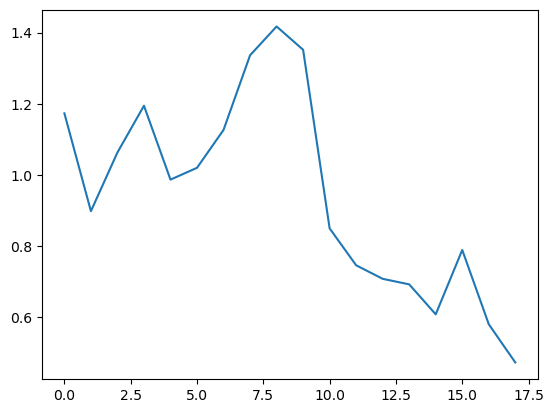

In [32]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-10-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_stay_location[(alison_stay_location['datetime'] >= date_20121001) & (alison_stay_location['datetime'] <= date_20121231)]
s2 = alison_stay_location[(alison_stay_location['datetime'] >= date_20131001) & (alison_stay_location['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
plt.plot(dist_list)

### compute pairwise distance between trajectory segments

In [47]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-10-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
sns.heatmap(np.flip(np.array(matrix),axis=1))

<Axes: >

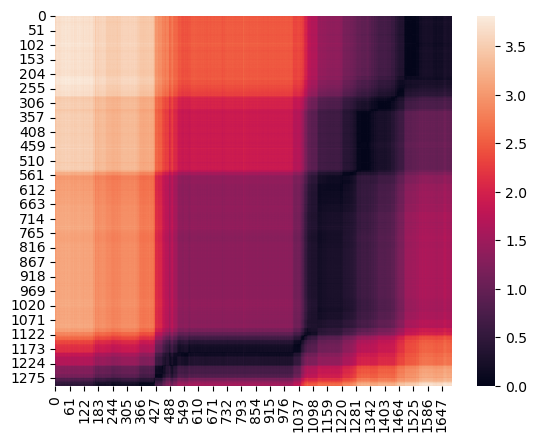

In [42]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-09-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
sns.heatmap(np.flip(np.array(matrix),axis=1))

In [40]:
sns.heatmap(np.array(matrix))

NameError: name 'matrix' is not defined

In [43]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-09-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2014-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
sns.heatmap(np.flip(np.array(matrix),axis=1))

<Axes: xlabel='datetime'>

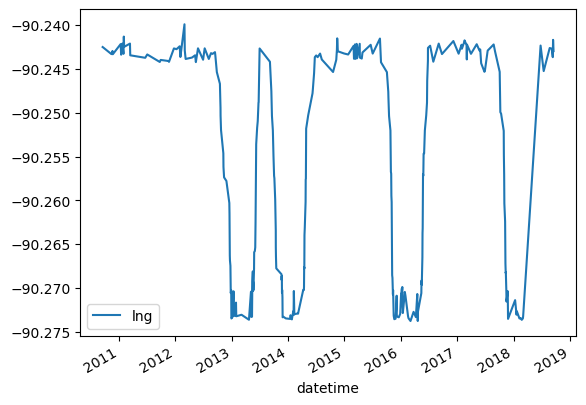

In [52]:
alison_stay_location.plot(x="datetime", y ="lng")

In [53]:
# cluster stops
tortoise_stay_clusters = clustering.cluster(tortoise_stay_location, cluster_radius_km=0.2, min_samples=1)

In [54]:
alison_stay_clusters = tortoise_stay_clusters.query("uid == 'Alison'")

In [55]:
color_list

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [56]:
m = alison_stay_clusters[alison_stay_clusters["cluster"] == 0].plot_stops(hex_color = color_list[0], zoom=14, radius = 5)
alison_stay_clusters[alison_stay_clusters["cluster"] == 1].plot_stops(map_f = m, hex_color = color_list[1], radius =5)
alison_stay_clusters[alison_stay_clusters["cluster"] == 2].plot_stops(map_f = m, hex_color = color_list[2], radius = 5)
m

<Axes: title={'center': 'user Alison'}>

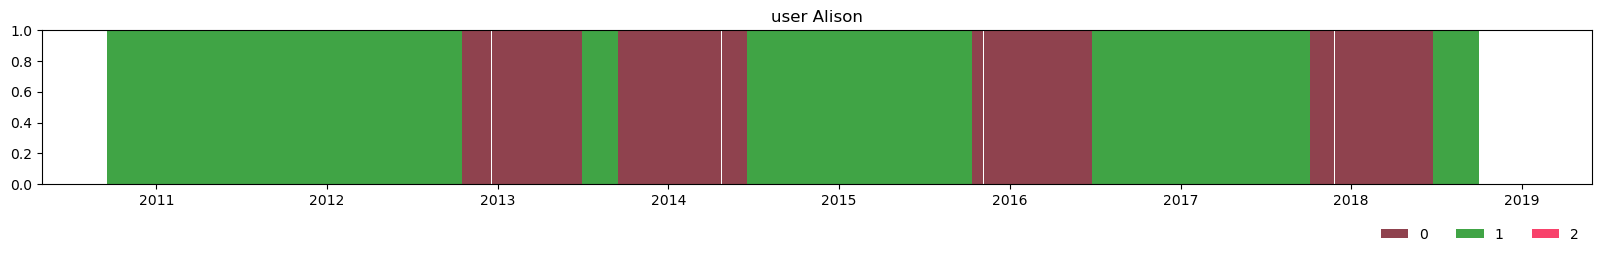

In [57]:
# plot the diary of one individual
user = "Alison"
start_datetime = pd.to_datetime('2010-05-01 030000').tz_localize(tz='US/Pacific')
end_datetime = pd.to_datetime('2019-05-31 030000').tz_localize(tz='US/Pacific')
tortoise_stay_clusters.plot_diary(user, start_datetime=start_datetime, end_datetime=end_datetime,legend=True)


<Axes: xlabel='timestamp_local', ylabel='location_long'>

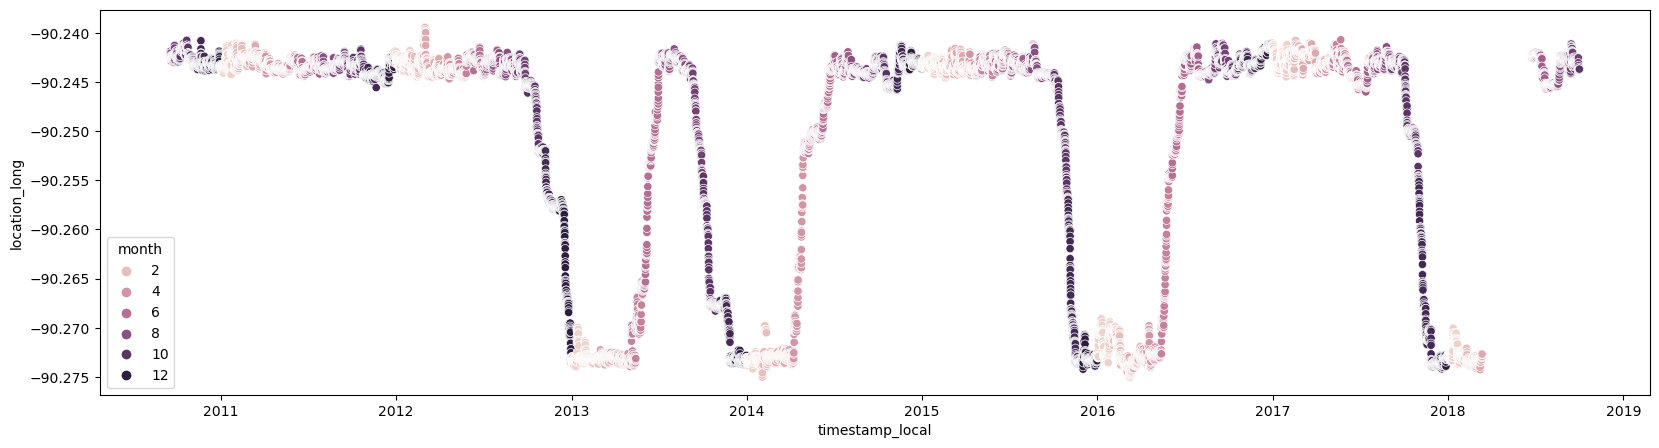

In [58]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_long", hue="month")

<Axes: xlabel='timestamp_local', ylabel='location_lat'>

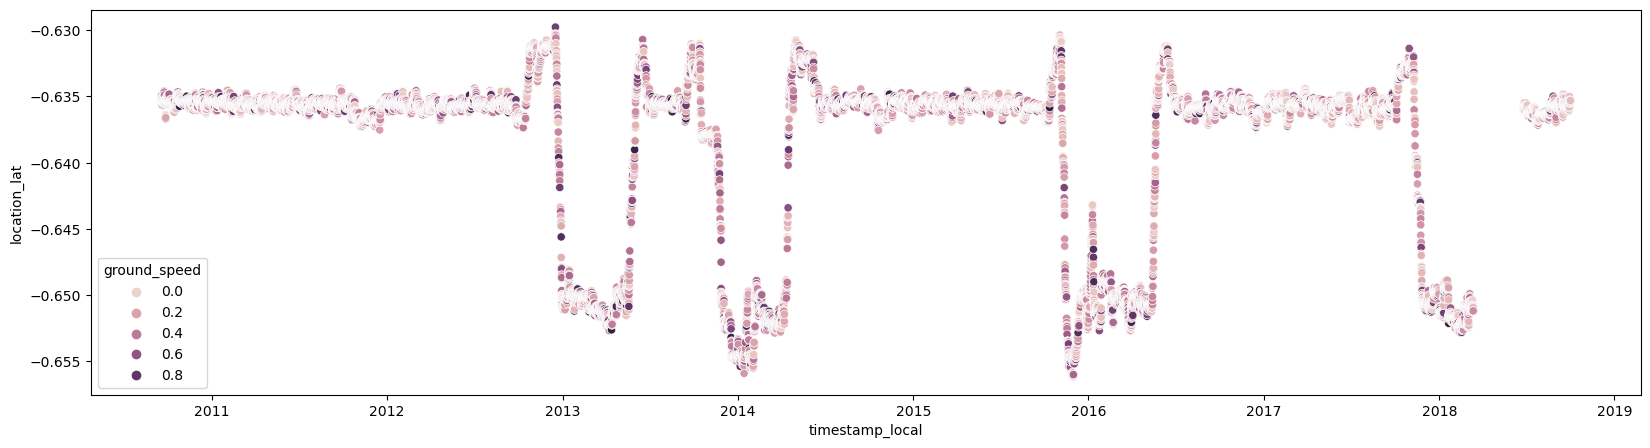

In [59]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_lat", hue="ground_speed")

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

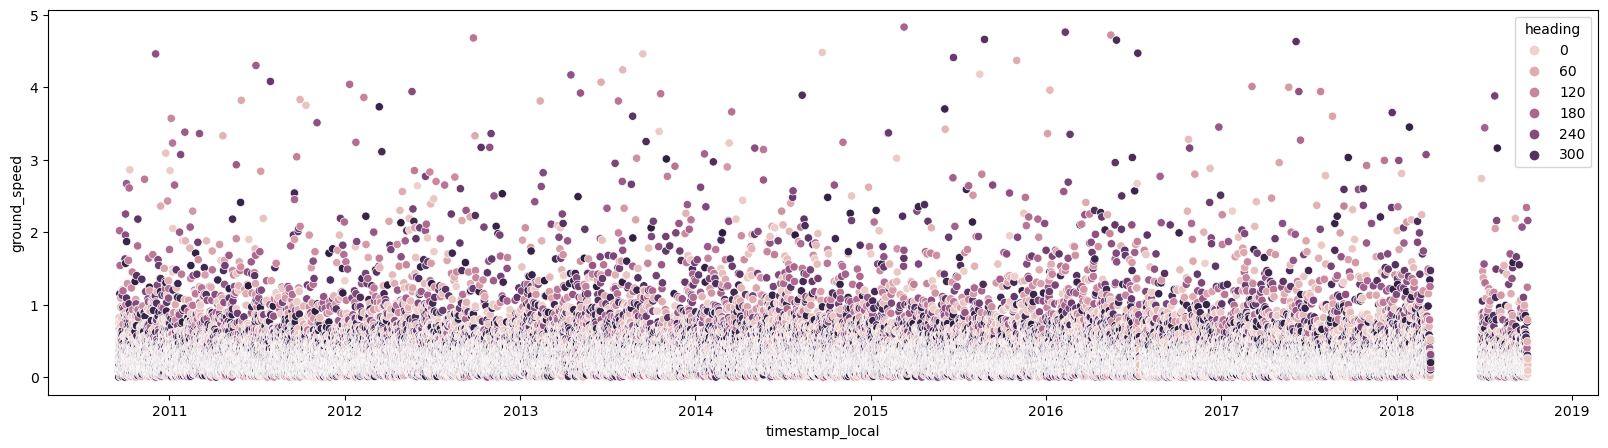

In [60]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <5") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="ground_speed", hue="heading")

<Axes: title={'center': 'user Christian'}>

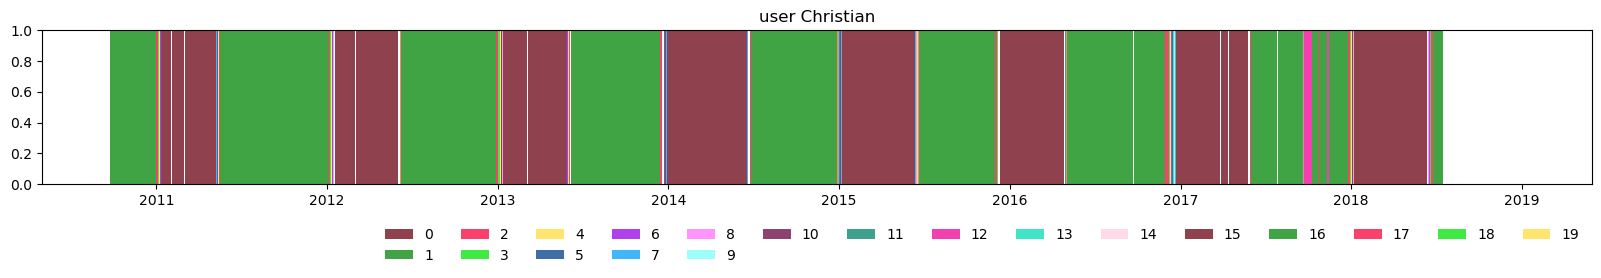

In [61]:
user = "Christian"
start_datetime = pd.to_datetime('2010-05-01 030000').tz_localize(tz='US/Pacific')
end_datetime = pd.to_datetime('2019-05-31 030000').tz_localize(tz='US/Pacific')
tortoise_stay_clusters.plot_diary(user, start_datetime=start_datetime, end_datetime=end_datetime,legend=True)

In [62]:
def invidual_lat_long(name, lat_long):
    plt.figure(figsize = (20,5))
    df_name = tortoise[tortoise["individual_local_identifier"] == name]
    sns.scatterplot(df_name, x = "timestamp", y=lat_long)


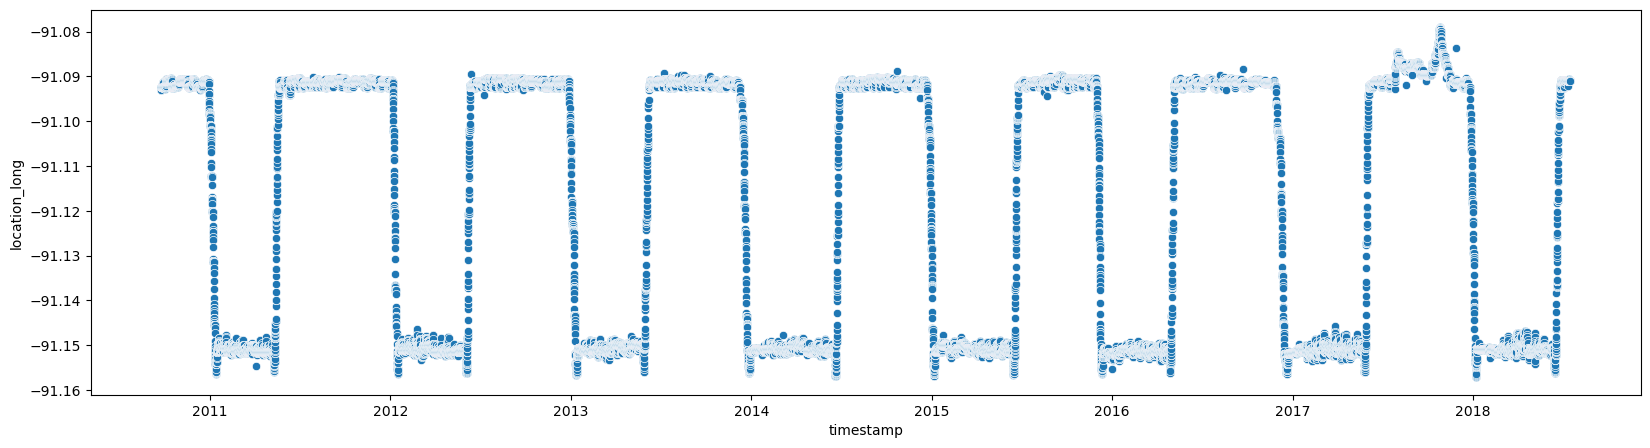

In [63]:
invidual_lat_long("Christian", "location_long")

In [64]:
temp_df = tortoise.groupby("individual_local_identifier").agg(max_time = ('timestamp', max), min_time = ('timestamp', min) )
temp_df["length"] = (temp_df.max_time - temp_df.min_time)
temp_df.sort_values(by="length", ascending=False)

,max_time,min_time,length
individual_local_identifier,,,
Sandra,2018-10-01 16:00:06.000,2010-05-28 17:00:21.998,3047 days 22:59:44.002000
Kitty,2018-10-01 16:00:29.998,2010-09-17 16:01:24.999,2935 days 23:59:04.999000
Alison,2018-10-01 16:00:29.998,2010-09-17 17:01:25.998,2935 days 22:59:04
Marilyn,2018-10-01 16:00:13.998,2010-09-17 18:01:31.998,2935 days 21:58:42
Steve Devine,2018-07-27 13:00:47.001,2010-09-20 22:01:25.001,2866 days 14:59:22
Greg,2018-07-22 15:00:25.998,2010-09-23 21:00:43.998,2858 days 17:59:42
Anne,2018-07-21 22:00:16.999,2010-09-23 22:00:51.001,2857 days 23:59:25.998000
Martin,2018-07-21 21:00:20.001,2010-09-23 22:00:58.999,2857 days 22:59:21.002000
Sparkey,2018-07-19 19:00:44.999,2010-09-23 17:00:49.998,2856 days 01:59:55.001000


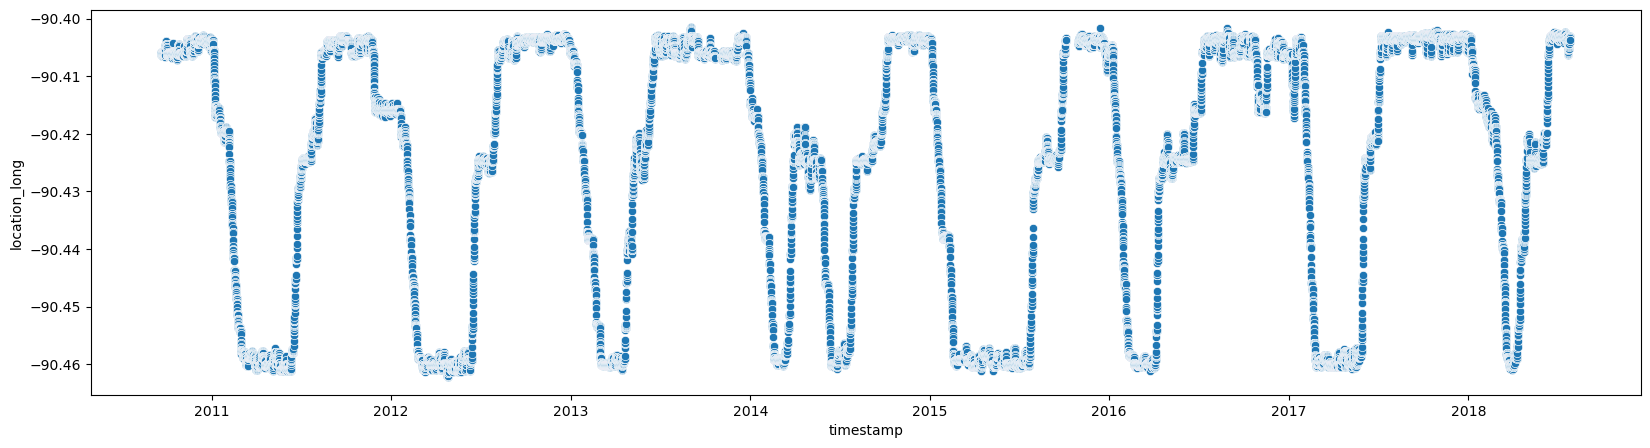

In [65]:
invidual_lat_long("Steve Devine", "location_long")

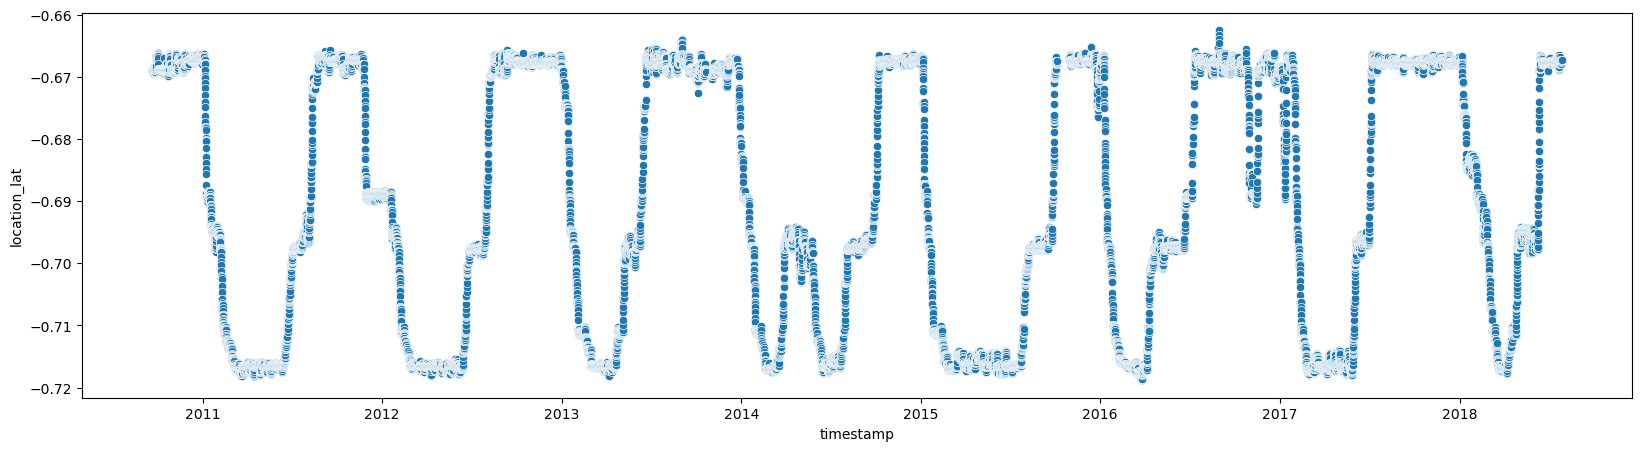

In [66]:
invidual_lat_long("Steve Devine", "location_lat")

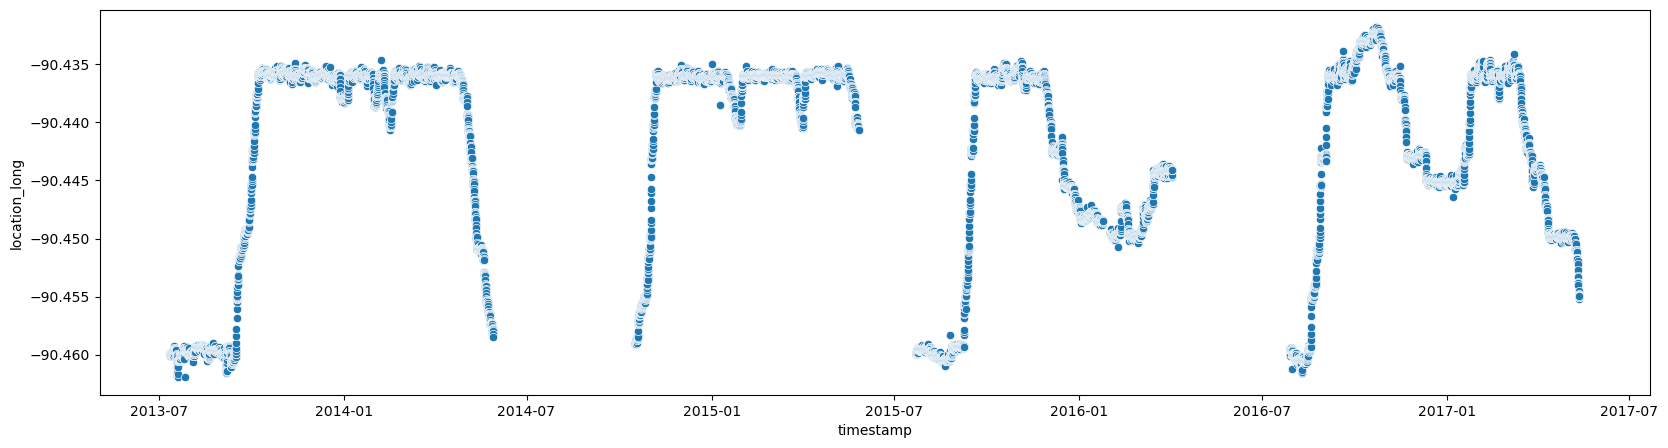

In [67]:
invidual_lat_long("Chrissie", "location_long")

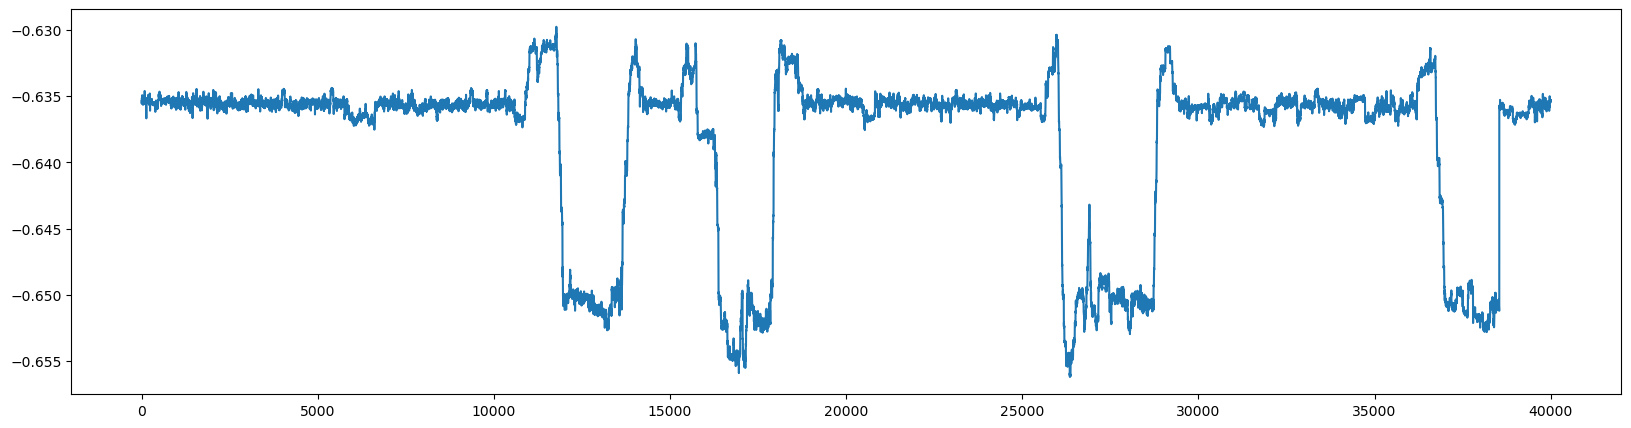

In [68]:
plt.figure(figsize = (20,5))
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]
plt.plot(alison.location_lat.values)

In [69]:
import skmob
from skmob.measures.individual import maximum_distance
tortoise_max_distance = maximum_distance(tortoise_trajectory)
tortoise_max_distance

100%|██████████| 96/96 [00:06<00:00, 14.81it/s]


,uid,maximum_distance
0,Alison,3.781776
1,Andrea,1.173420
2,Andres,0.711277
3,Anne,0.688293
4,Bill,1.053307
5,Birgit,0.368320
6,Carolina,1.518231
7,Charles,0.382068
8,Chica,0.560945
9,Chrissie,3.249870


In [70]:
from skmob.measures.individual import number_of_locations
tortoise_num_locations = number_of_locations(tortoise_trajectory)
tortoise_num_locations

100%|██████████| 96/96 [00:16<00:00,  5.90it/s]


,uid,number_of_locations
0,Alison,40002
1,Andrea,1519
2,Andres,3739
3,Anne,41109
4,Bill,1814
5,Birgit,28311
6,Carolina,45354
7,Charles,9178
8,Chica,1754
9,Chrissie,25349


In [71]:
alison_trajectory = skmob.TrajDataFrame(alison, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local', \
)
print(alison_trajectory.head())

         event_id               timestamp                    timestamp_UTC  \
1290187  46119277 2010-09-17 17:01:25.998 2010-09-17 17:01:25.998000+00:00   
1290188  46119278 2010-09-17 18:00:58.001 2010-09-17 18:00:58.001000+00:00   
1290189  46119279 2010-09-17 19:00:56.001 2010-09-17 19:00:56.001000+00:00   
1290190  46119280 2010-09-17 20:00:29.000        2010-09-17 20:00:29+00:00   
1290191  46119281 2010-09-17 21:00:56.000        2010-09-17 21:00:56+00:00   

                                datetime  minute_diff        lng       lat  \
1290187 2010-09-17 10:01:25.998000-07:00            0 -90.241889 -0.635366   
1290188 2010-09-17 11:00:58.001000-07:00           59 -90.242230 -0.635563   
1290189 2010-09-17 12:00:56.001000-07:00           59 -90.242210 -0.635515   
1290190        2010-09-17 13:00:29-07:00           59 -90.242227 -0.635356   
1290191        2010-09-17 14:00:56-07:00           60 -90.242101 -0.635276   

         eobs_temperature  ground_speed  heading  height_above

<Axes: >

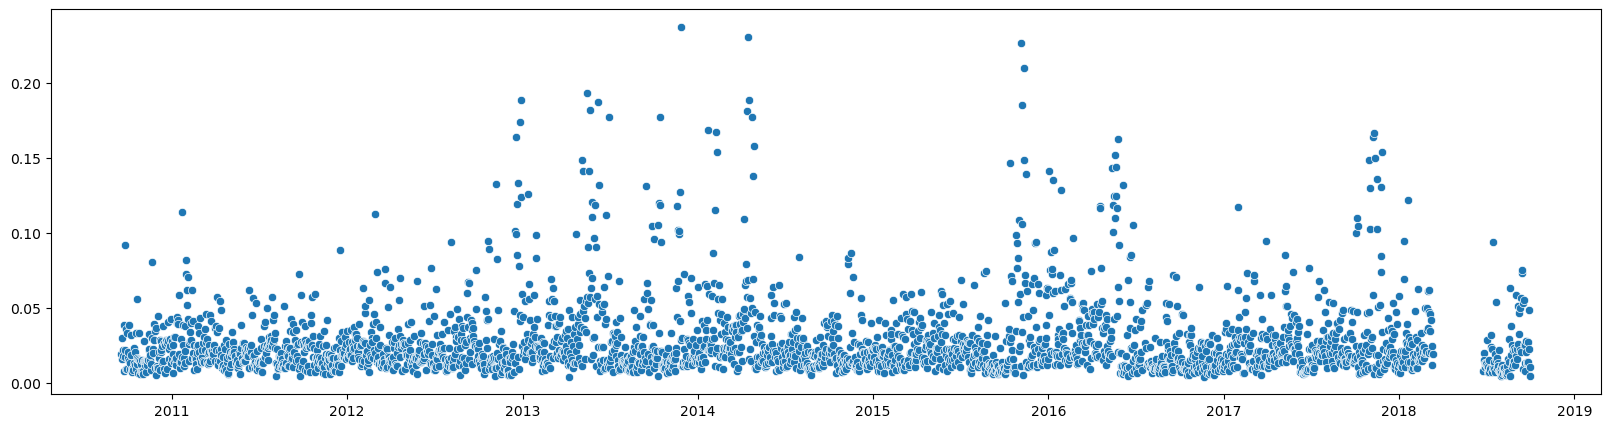

In [72]:
from skmob.measures.individual import radius_of_gyration
alison_rog = []
date_list = []
for date in alison.date.unique():
    date_list.append(date)
    #rog = radius_of_gyration(alison_trajectory[alison_trajectory["date"] == date],show_progress=False)["radius_of_gyration"][0]
    #alison_rog.append(rog)
    alison_rog.append(radius_of_gyration(alison_trajectory[alison_trajectory["date"] == date], show_progress=False)["radius_of_gyration"])
plt.figure(figsize = (20,5))
sns.scatterplot(x=date_list, y=np.array(alison_rog).ravel())

<Axes: xlabel='timestamp_local', ylabel='location_long'>

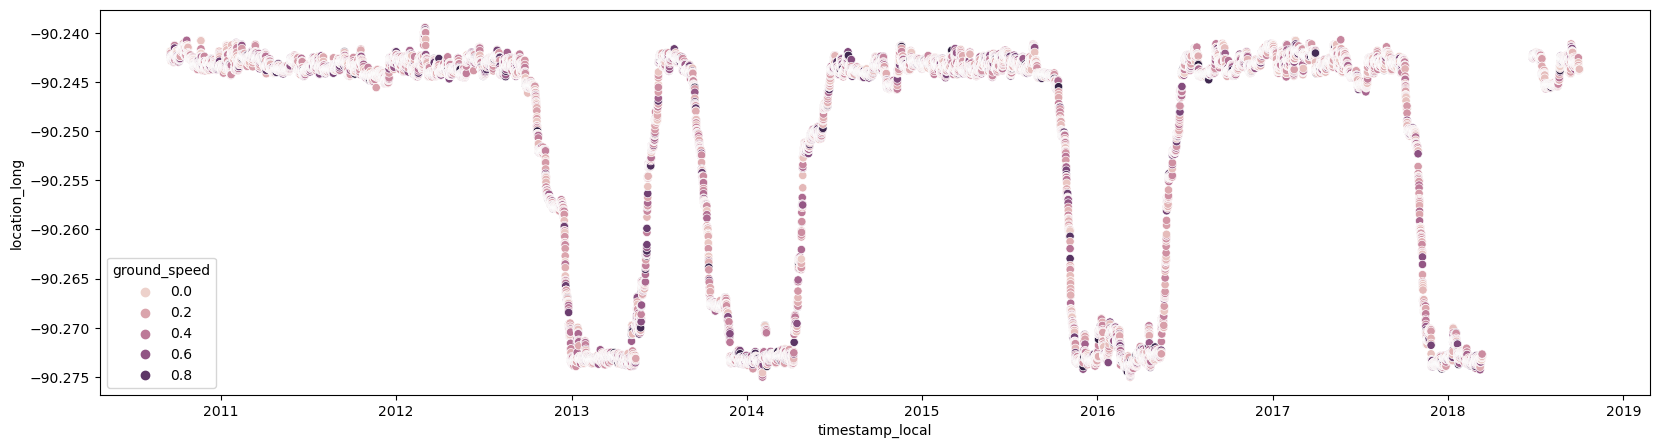

In [73]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_long", hue="ground_speed")


<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

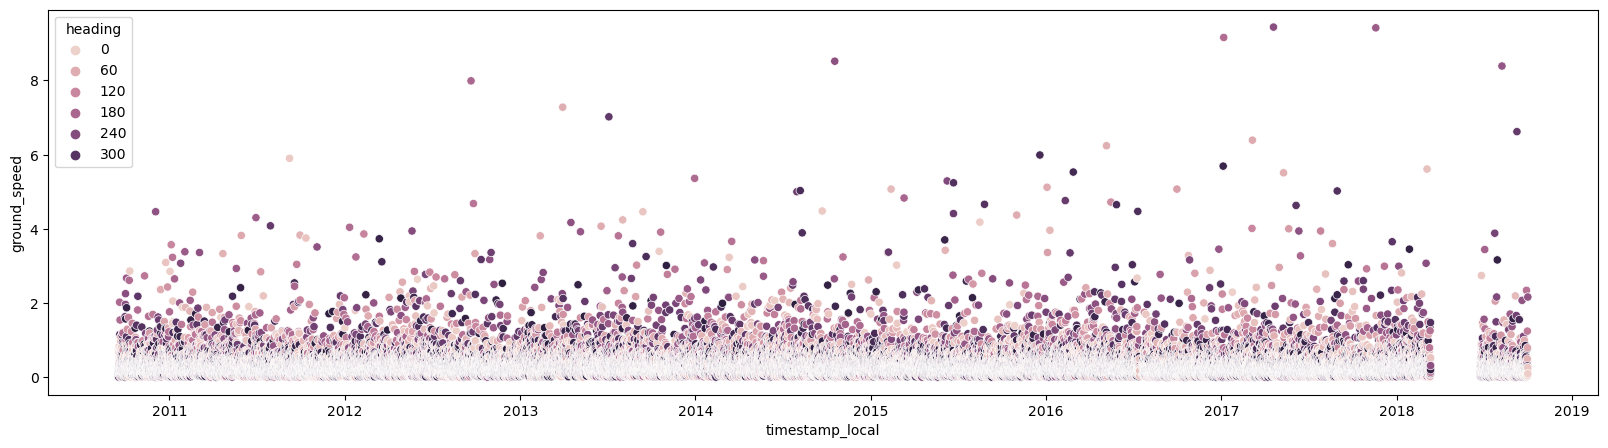

In [74]:
plt.figure(figsize = (20,5))
temp_df = tortoise.query("individual_local_identifier == 'Alison' and ground_speed < 10") # ground_speed unit is meters per second
sns.scatterplot(temp_df, x = "timestamp_local", y="ground_speed", hue="heading")


<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

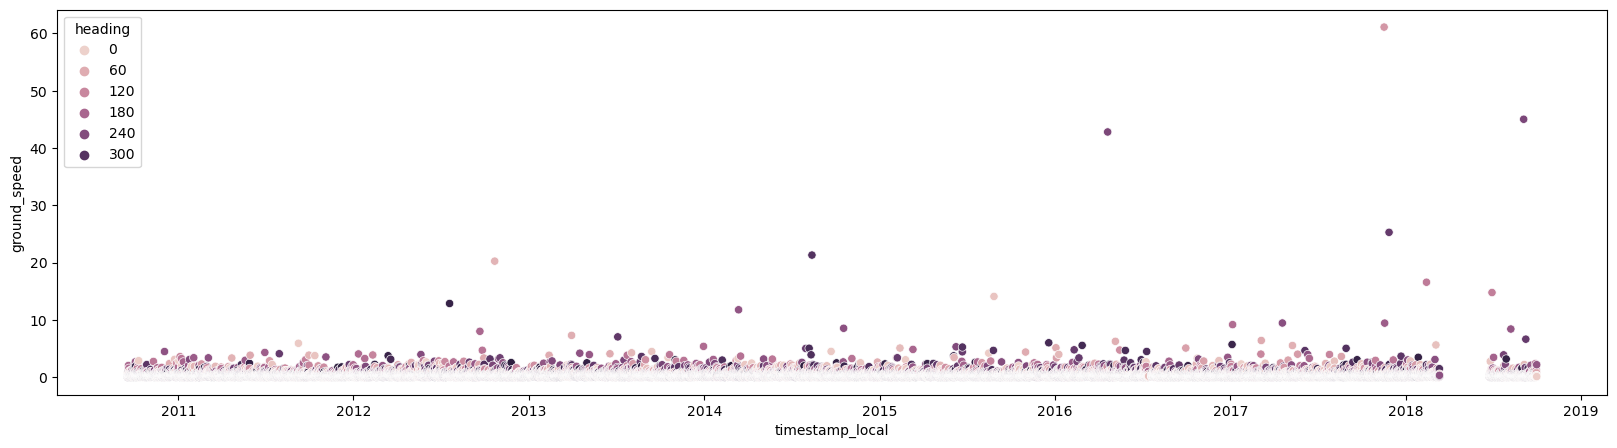

In [75]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison'") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="ground_speed", hue="heading")
